In [1]:
import numpy as np
import  pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:

df.info()
df.isnull().sum()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


## Handle Missiong Value

In [4]:
# Separate numerical columns
df_numerical = df.select_dtypes(include=["float64"]).columns

# Separate categorical columns (using 'object' for string-based categories)
df_categorical = df.select_dtypes(include=["object"]).columns

In [5]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy='mean')
df[df_numerical] = num_imp.fit_transform(df[df_numerical])


In [6]:
cat_imp = SimpleImputer(strategy='most_frequent')
df[df_categorical] = cat_imp.fit_transform(df[df_categorical])

In [7]:
df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

## Exploratory data Analysis

Text(0.5, 1.0, 'Is Loan approved or not')

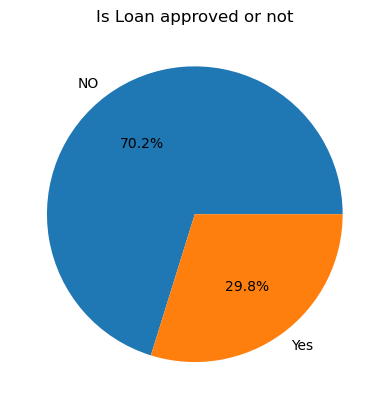

In [8]:
# how balanced our classes are

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["NO","Yes"] ,autopct="%1.1f%%")

plt.title("Is Loan approved or not")

[Text(0, 0, '517'), Text(0, 0, '294'), Text(0, 0, '189')]

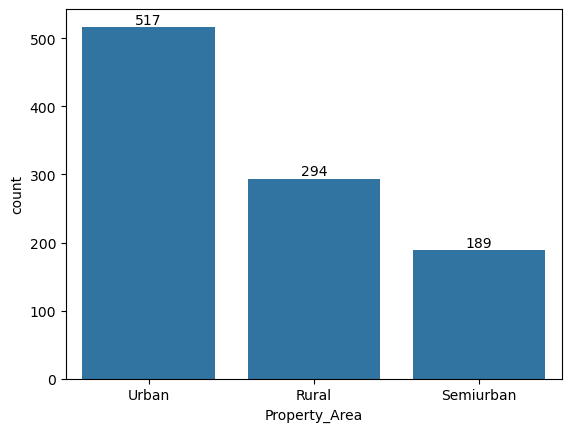

In [9]:
# gender analysis

# gender_count = df["Gender"].value_counts()
# ax= sns.barplot(gender_count)
# ax.bar_label(ax.containers[0])

# educ_count = df["Education_Level"].value_counts()
# ax= sns.barplot(educ_count)
# ax.bar_label(ax.containers[0])


# loanpur_count = df["Loan_Purpose"].value_counts()
# ax= sns.barplot(loanpur_count)
# ax.bar_label(ax.containers[0])

# empcat_count = df["Employer_Category"].value_counts()
# ax= sns.barplot(empcat_count)
# ax.bar_label(ax.containers[0])

pro_count = df["Property_Area"].value_counts()
ax= sns.barplot(pro_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

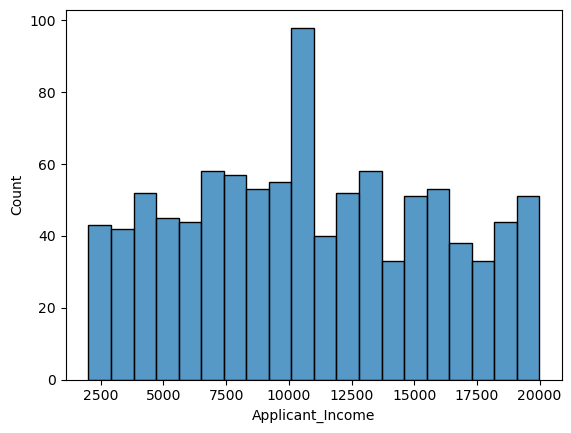

In [10]:
# analyze income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

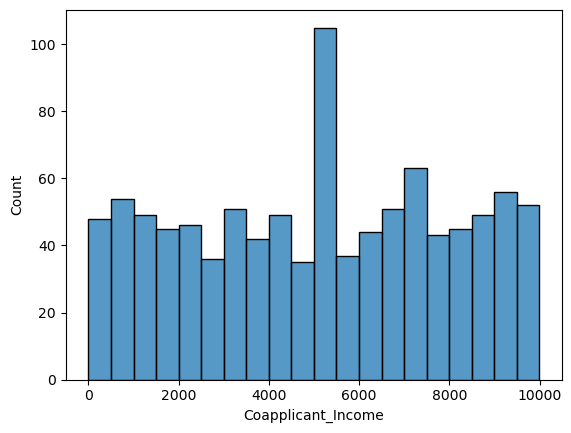

In [11]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

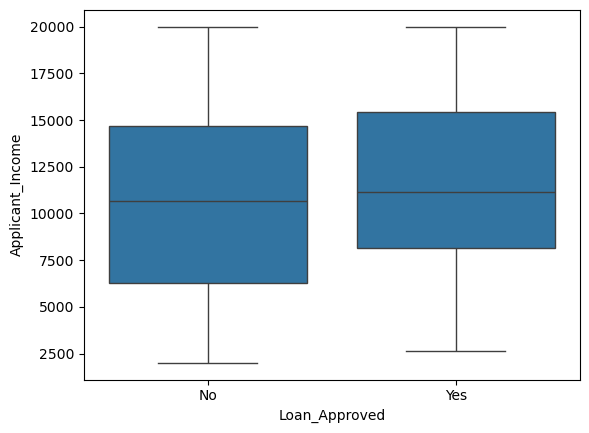

In [12]:
#  outlers - boxplot

sns.boxplot(
    data =df,
    x= "Loan_Approved",
    y="Applicant_Income"
)

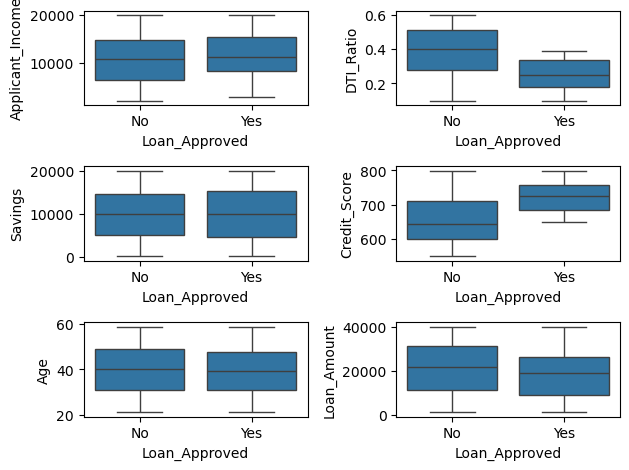

In [13]:
fig ,axes = plt.subplots(3,2)
sns.boxplot(ax=axes[0,0],data =df,x= "Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data =df,x= "Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,0],data =df,x= "Loan_Approved",y="Savings")
sns.boxplot(ax=axes[1,1],data =df,x= "Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[2,0],data =df,x= "Loan_Approved",y="Age")
sns.boxplot(ax=axes[2,1],data =df,x= "Loan_Approved",y="Loan_Amount")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

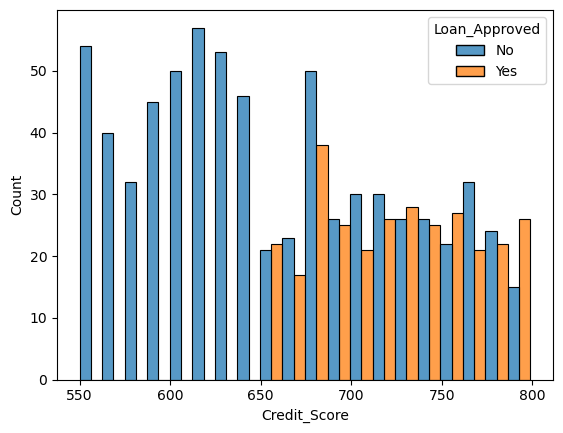

In [14]:
sns.histplot(
    data= df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins= 20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

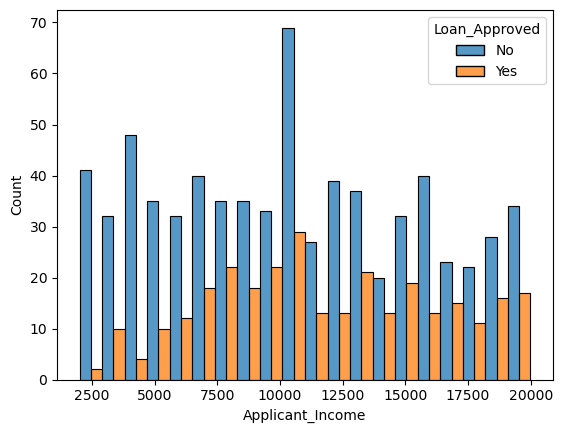

In [15]:
sns.histplot(
    data= df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins= 20,
    multiple="dodge"
)

In [16]:
#  remove applicant_id

df = df.drop("Applicant_ID" ,axis = 1)

In [17]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

# Feature Engineering

In [18]:
from sklearn.preprocessing import LabelEncoder ,OneHotEncoder
le = LabelEncoder()
df["Education_Level"]= le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])




In [19]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [20]:
cols=["Gender","Marital_Status","Loan_Purpose","Property_Area","Employer_Category","Employment_Status"]

ohe=OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False)

encoded = ohe.fit_transform(df[cols])

encoded_df=pd.DataFrame(encoded,columns= ohe.get_feature_names_out(cols),index=df.index)

df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [21]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int32  
 12  Loan_Approved        

# Correlation HeatMap

<Axes: >

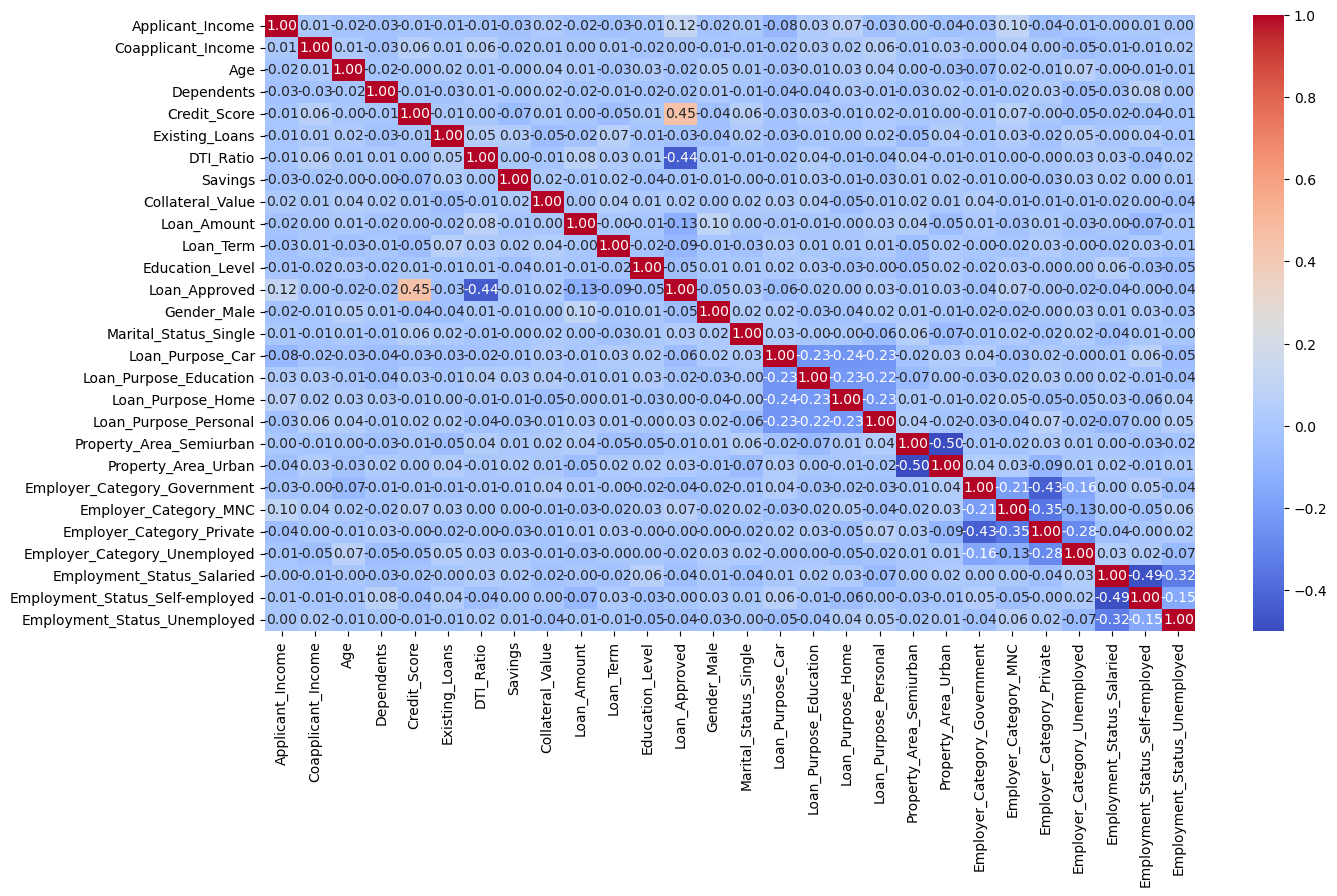

In [22]:
num_cols = df.select_dtypes(include="number")
corr_matrix= num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap="coolwarm"
)

In [23]:
# matrix correction of loan approved with every numarical col
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# Train-Test-split + feature scaling

In [24]:
x= df.drop("Loan_Approved",axis = 1)
y= df["Loan_Approved"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [26]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [27]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [28]:
X_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -1.03563452,
        -0.48235427,  3.20431048],
       [ 1.00971366,  0.58995935,  0.18392964, ...,  0.96559161,
        -0.48235427, -0.31207962],
       [-0.67557096, -0.54558674,  1.09887608, ...,  0.96559161,
        -0.48235427, -0.31207962],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -1.03563452,
        -0.48235427, -0.31207962],
       [-0.37650705, -0.97825874, -0.54802752, ...,  0.96559161,
        -0.48235427, -0.31207962],
       [-0.73647272, -1.24497436,  0.73289751, ..., -1.03563452,
         2.07316503, -0.31207962]])

# Train & Evaluate Model

In [29]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,recall_score,f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred= log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("CM:", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision: 0.7833333333333333
Recall: 0.7704918032786885
F1 Score: 0.7768595041322314
Accuracy: 0.865
CM: [[126  13]
 [ 14  47]]


In [30]:
# KNN 
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)
y_pred= knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Model")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("CM:", confusion_matrix(y_test, y_pred))

KNN Model
Precision: 0.6274509803921569
Recall: 0.5245901639344263
F1 Score: 0.5714285714285714
Accuracy: 0.76
CM: [[120  19]
 [ 29  32]]


In [31]:
# Navie baiyes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)
y_pred= nb_model.predict(X_test_scaled)

# Evaluation
print("Naive bayies Model")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("CM:", confusion_matrix(y_test, y_pred))

Naive bayies Model
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1 Score: 0.7692307692307693
Accuracy: 0.865
CM: [[128  11]
 [ 16  45]]


### Best model on the basis of precision => Logistic Regression